In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [2]:
# ── Paths ──────────────────────────────────────────
TRAIN_DIR = "12-way script classification dataset/train_1800"
TEST_DIR  = "12-way script classification dataset/test_478"

# ── Hyperparameters ────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS_FROZEN   = 15    # Phase 1: train head only
EPOCHS_FINETUNE = 35    # Phase 2: fine-tune top layers
NUM_CLASSES  = 12
DROPOUT_RATE = 0.5
L2_REG       = 1e-4
LR_HEAD      = 1e-3     # Phase 1 LR
LR_FINETUNE  = 1e-5     # Phase 2 LR

# Output folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/checkpoints", exist_ok=True)

print("Config ready ✅")

Config ready ✅


In [3]:
# ── Training augmentation (heavy — fights overfitting) ─
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20,
    fill_mode='nearest',
    validation_split=0.15          # 15% of train → validation
)

# ── Test/Val: only rescale ─────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

# ── Generators ────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Classes:", CLASS_NAMES)
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

Found 17984 images belonging to 12 classes.
Found 3173 images belonging to 12 classes.
Found 5736 images belonging to 12 classes.
Classes: ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Train: 17984 | Val: 3173 | Test: 5736


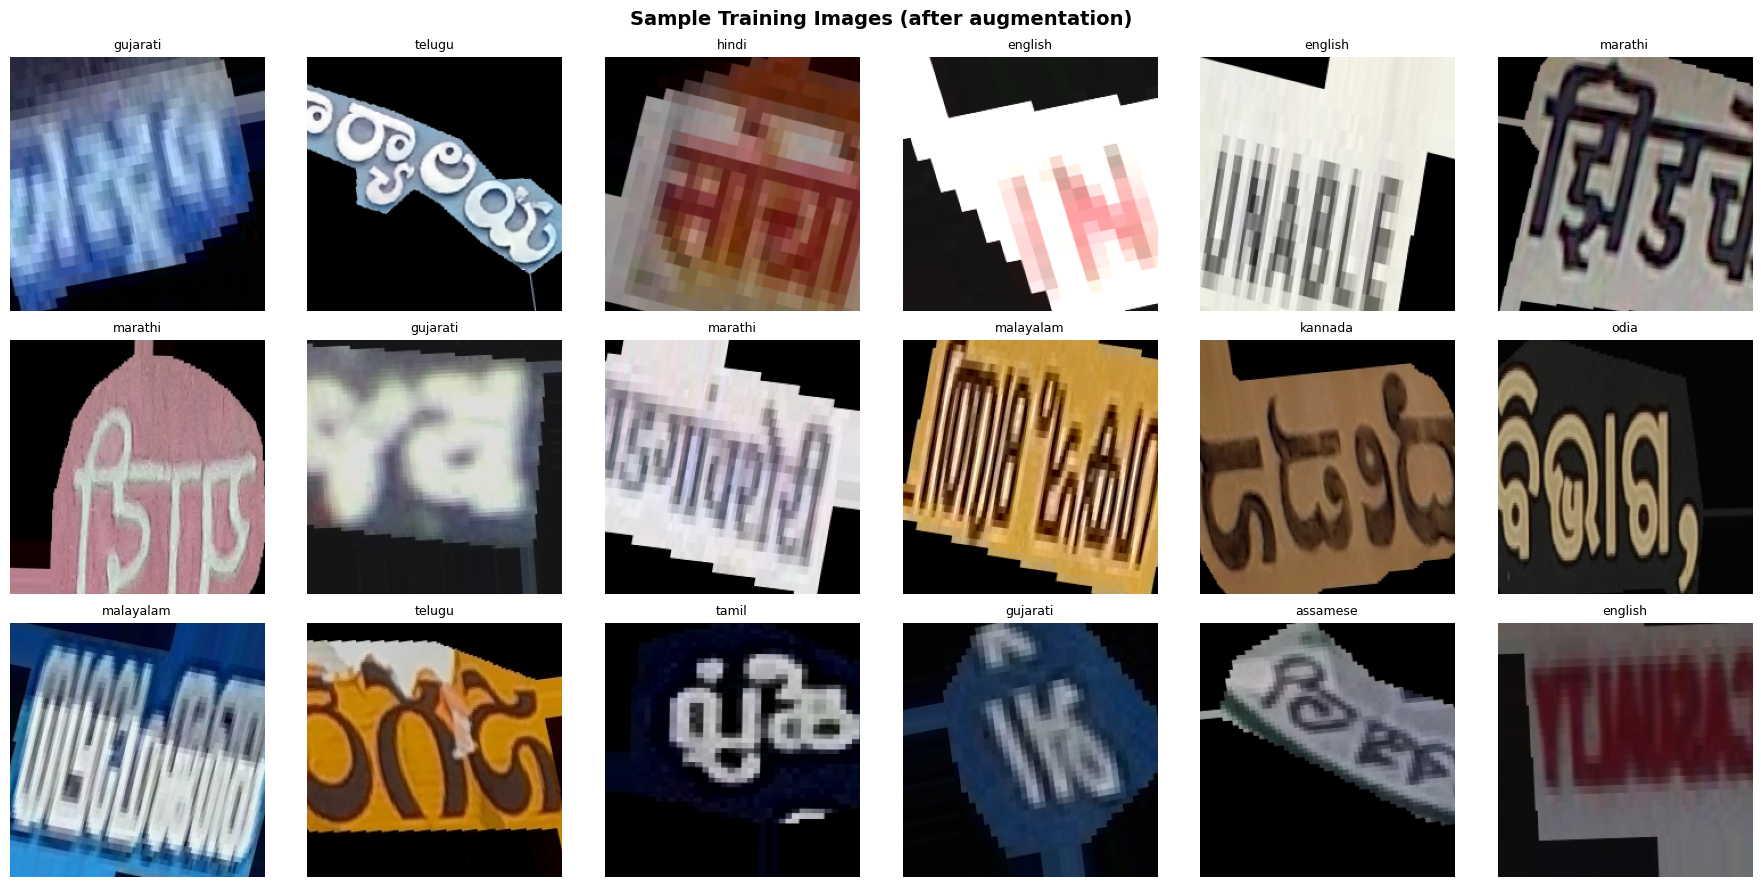

In [4]:
images, labels = next(train_gen)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i in range(18):
    axes[i].imshow(images[i])
    axes[i].set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Training Images (after augmentation)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

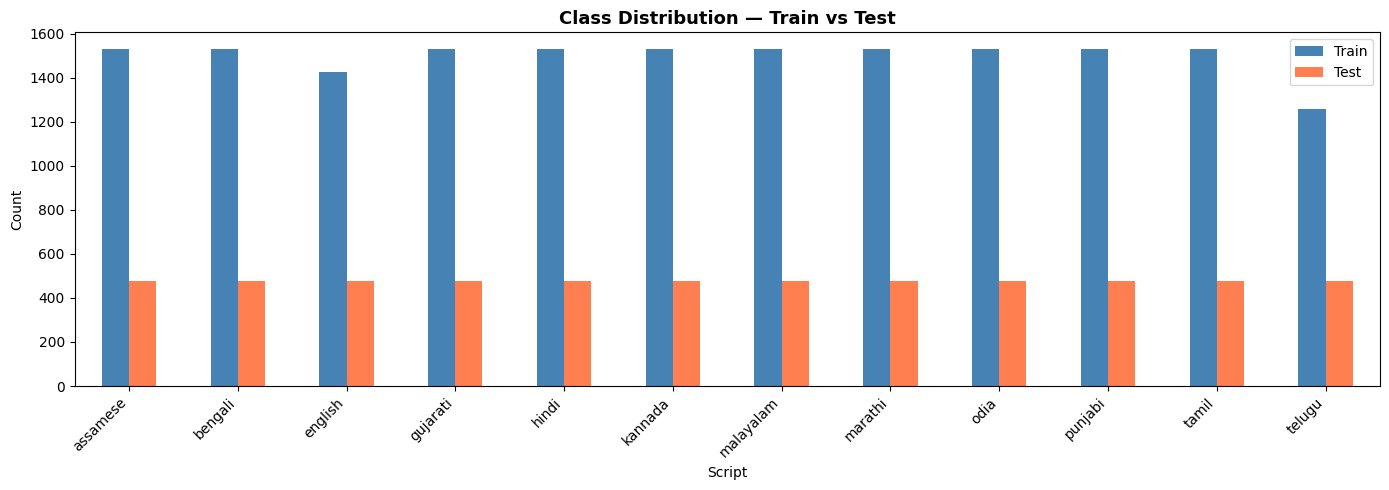

   Script  Train  Test
 assamese   1530   478
  bengali   1530   478
  english   1428   478
 gujarati   1530   478
    hindi   1530   478
  kannada   1530   478
malayalam   1530   478
  marathi   1530   478
     odia   1530   478
  punjabi   1530   478
    tamil   1530   478
   telugu   1256   478


In [6]:
from collections import Counter
train_counts = dict(Counter(train_gen.classes))
test_counts  = dict(Counter(test_gen.classes))

train_df = pd.DataFrame({
    'Script': [CLASS_NAMES[i] for i in sorted(train_counts)],
    'Train':  [train_counts[i] for i in sorted(train_counts)],
    'Test':   [test_counts.get(i, 0) for i in sorted(train_counts)]
})

train_df.set_index('Script').plot(kind='bar', figsize=(14, 5),
                                   color=['steelblue','coral'])
plt.title("Class Distribution — Train vs Test", fontsize=13, fontweight='bold')
plt.ylabel("Count"); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=150)
plt.show()
print(train_df.to_string(index=False))

In [7]:
def build_model(num_classes=NUM_CLASSES, dropout=DROPOUT_RATE, l2=L2_REG):
    # ── Base: ResNet50V2 pretrained on ImageNet ─────
    base = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling=None
    )
    base.trainable = False          # Freeze in phase 1

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Data augmentation inside model (runs only during training)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.1)(x)
    
    x = base(x, training=False)    # BN layers stay frozen in phase 1
    
    # ── Custom Head ────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.6)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax',
                            dtype='float32')(x)

    model = keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model()
model.summary()
print(f"\nTotal params:     {model.count_params():,}")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,759,564 (94.45 MB)

 Trainable params: 1,189,132 (4.54 MB)

 Non-trainable params: 23,570,432 (89.91 MB)


Total params:     24,759,564
Trainable params: 1,189,132


In [8]:
# ── Callbacks ──────────────────────────────────────
def get_callbacks(prefix, monitor='val_accuracy'):
    return [
        EarlyStopping(monitor=monitor, patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.4,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f"outputs/checkpoints/{prefix}_best.keras",
                        monitor=monitor, save_best_only=True, verbose=1)
    ]

# ── Compute class weights to handle imbalance ─────
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", {CLASS_NAMES[k]: round(v,3) for k,v in class_weights.items()})

# ── Compile Phase 1 ───────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print("\n🚀 Phase 1: Training classification head (base frozen)...")
history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('phase1'),
    verbose=1
)

Class weights: {'assamese': np.float64(0.98), 'bengali': np.float64(0.98), 'english': np.float64(1.049), 'gujarati': np.float64(0.98), 'hindi': np.float64(0.98), 'kannada': np.float64(0.98), 'malayalam': np.float64(0.98), 'marathi': np.float64(0.98), 'odia': np.float64(0.98), 'punjabi': np.float64(0.98), 'tamil': np.float64(0.98), 'telugu': np.float64(1.193)}

🚀 Phase 1: Training classification head (base frozen)...
Epoch 1/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.2252 - loss: 2.4858 - top3_acc: 0.4945  
Epoch 1: val_accuracy improved from None to 0.34857, saving model to outputs/checkpoints/phase1_best.keras

Epoch 1: finished saving model to outputs/checkpoints/phase1_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 446s 784ms/step - accuracy: 0.2818 - loss: 2.2736 - top3_acc: 0.5774 - val_accuracy: 0.3486 - val_loss: 2.0139 - val_top3_acc: 0.6795 - learning_rate: 0.0010
Epoch 2/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.3588 - loss: 1.9988 - top3_acc: 0.68

In [9]:
# Unfreeze top 50 layers of ResNet50V2
base_model.trainable = True
UNFREEZE_FROM = len(base_model.layers) - 50

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)
    # Keep BatchNorm frozen to prevent distribution shift
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreeze: {trainable_count}")

# ── Compile Phase 2 (lower LR) ────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print("\n🔥 Phase 2: Fine-tuning top ResNet layers...")
history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('phase2'),
    verbose=1
)

Trainable layers after unfreeze: 16

🔥 Phase 2: Fine-tuning top ResNet layers...
Epoch 1/35
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.5407 - loss: 1.5723 - top3_acc: 0.8309  
Epoch 1: val_accuracy improved from None to 0.47747, saving model to outputs/checkpoints/phase2_best.keras

Epoch 1: finished saving model to outputs/checkpoints/phase2_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 548s 965ms/step - accuracy: 0.5560 - loss: 1.5240 - top3_acc: 0.8432 - val_accuracy: 0.4775 - val_loss: 1.6285 - val_top3_acc: 0.8254 - learning_rate: 1.0000e-05
Epoch 2/35
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.5942 - loss: 1.4044 - top3_acc: 0.8760  
Epoch 2: val_accuracy improved from 0.47747 to 0.52253, saving model to outputs/checkpoints/phase2_best.keras

Epoch 2: finished saving model to outputs/checkpoints/phase2_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 533s 949ms/step - accuracy: 0.5966 - loss: 1.3971 - top3_acc: 0.8756 - val_accuracy: 0.5225 - val_loss: 1.5380 - val_t

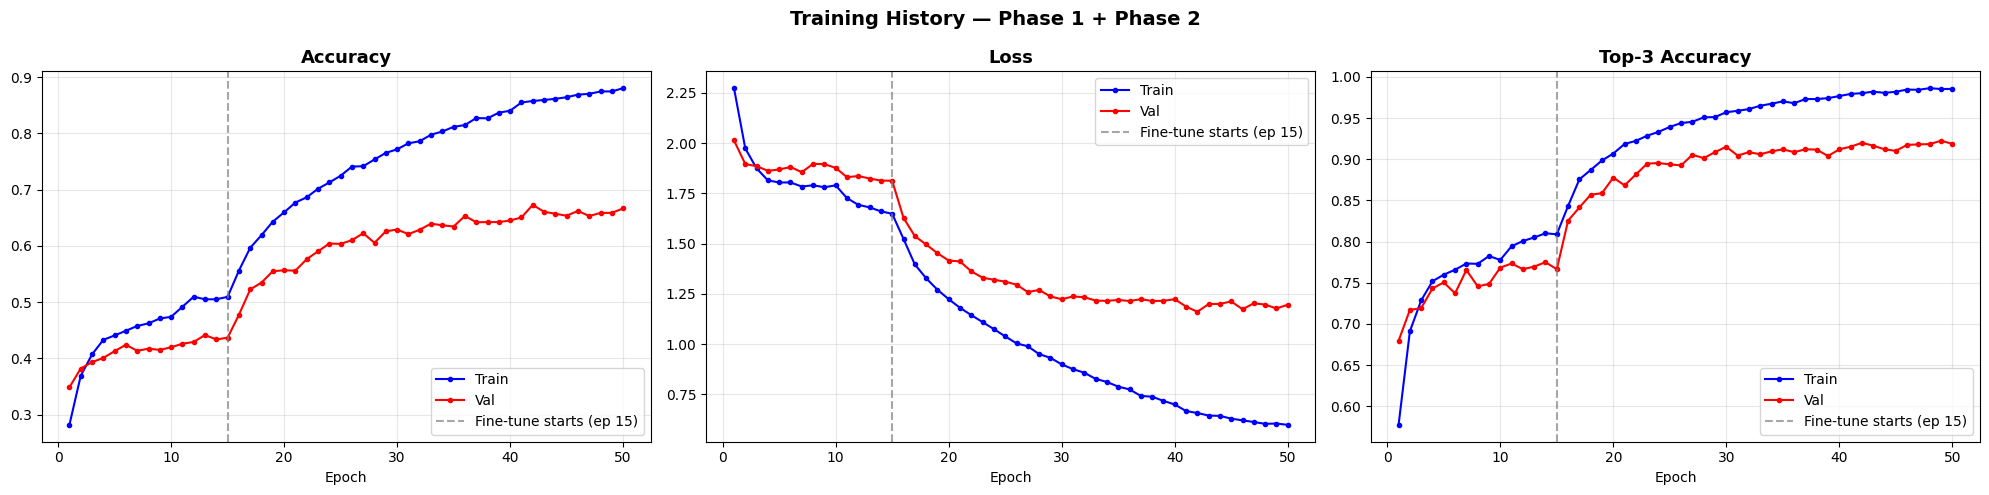

In [10]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_histories(history1, history2)
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = [
    ('accuracy',     'val_accuracy',     'Accuracy'),
    ('loss',         'val_loss',         'Loss'),
    ('top3_acc',     'val_top3_acc',     'Top-3 Accuracy'),
]

for ax, (train_k, val_k, title) in zip(axes, metrics):
    epochs = range(1, len(history[train_k]) + 1)
    ax.plot(epochs, history[train_k], 'b-o', ms=3, label='Train')
    ax.plot(epochs, history[val_k],   'r-o', ms=3, label='Val')
    ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.7,
               label=f'Fine-tune starts (ep {phase1_end})')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Training History — Phase 1 + Phase 2", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Test-Time Augmentation (TTA) for better accuracy ─
def tta_predict(model, generator, n_aug=5):
    """Average predictions over N augmented versions of each image."""
    # First get true labels (no shuffle)
    y_true = generator.classes

    # TTA augmentation
    tta_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )
    
    all_preds = []
    for _ in range(n_aug):
        tta_gen = tta_datagen.flow_from_directory(
            TEST_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False,
            seed=random.randint(0, 999)
        )
        preds = model.predict(tta_gen, verbose=0)
        all_preds.append(preds)
    
    avg_preds = np.mean(all_preds, axis=0)
    y_pred = np.argmax(avg_preds, axis=1)
    return y_true, y_pred, avg_preds

print("⏳ Running TTA predictions (5 augmentations)...")
y_true, y_pred, y_prob = tta_predict(model, test_gen, n_aug=5)

test_acc = accuracy_score(y_true, y_pred)
bal_acc  = balanced_accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy       : {test_acc*100:.2f}%")
print(f"✅ Balanced Accuracy   : {bal_acc*100:.2f}%")

⏳ Running TTA predictions (5 augmentations)...
Found 5736 images belonging to 12 classes.
Found 5736 images belonging to 12 classes.
Found 5736 images belonging to 12 classes.
Found 5736 images belonging to 12 classes.
Found 5736 images belonging to 12 classes.

✅ Test Accuracy       : 74.39%
✅ Balanced Accuracy   : 74.39%


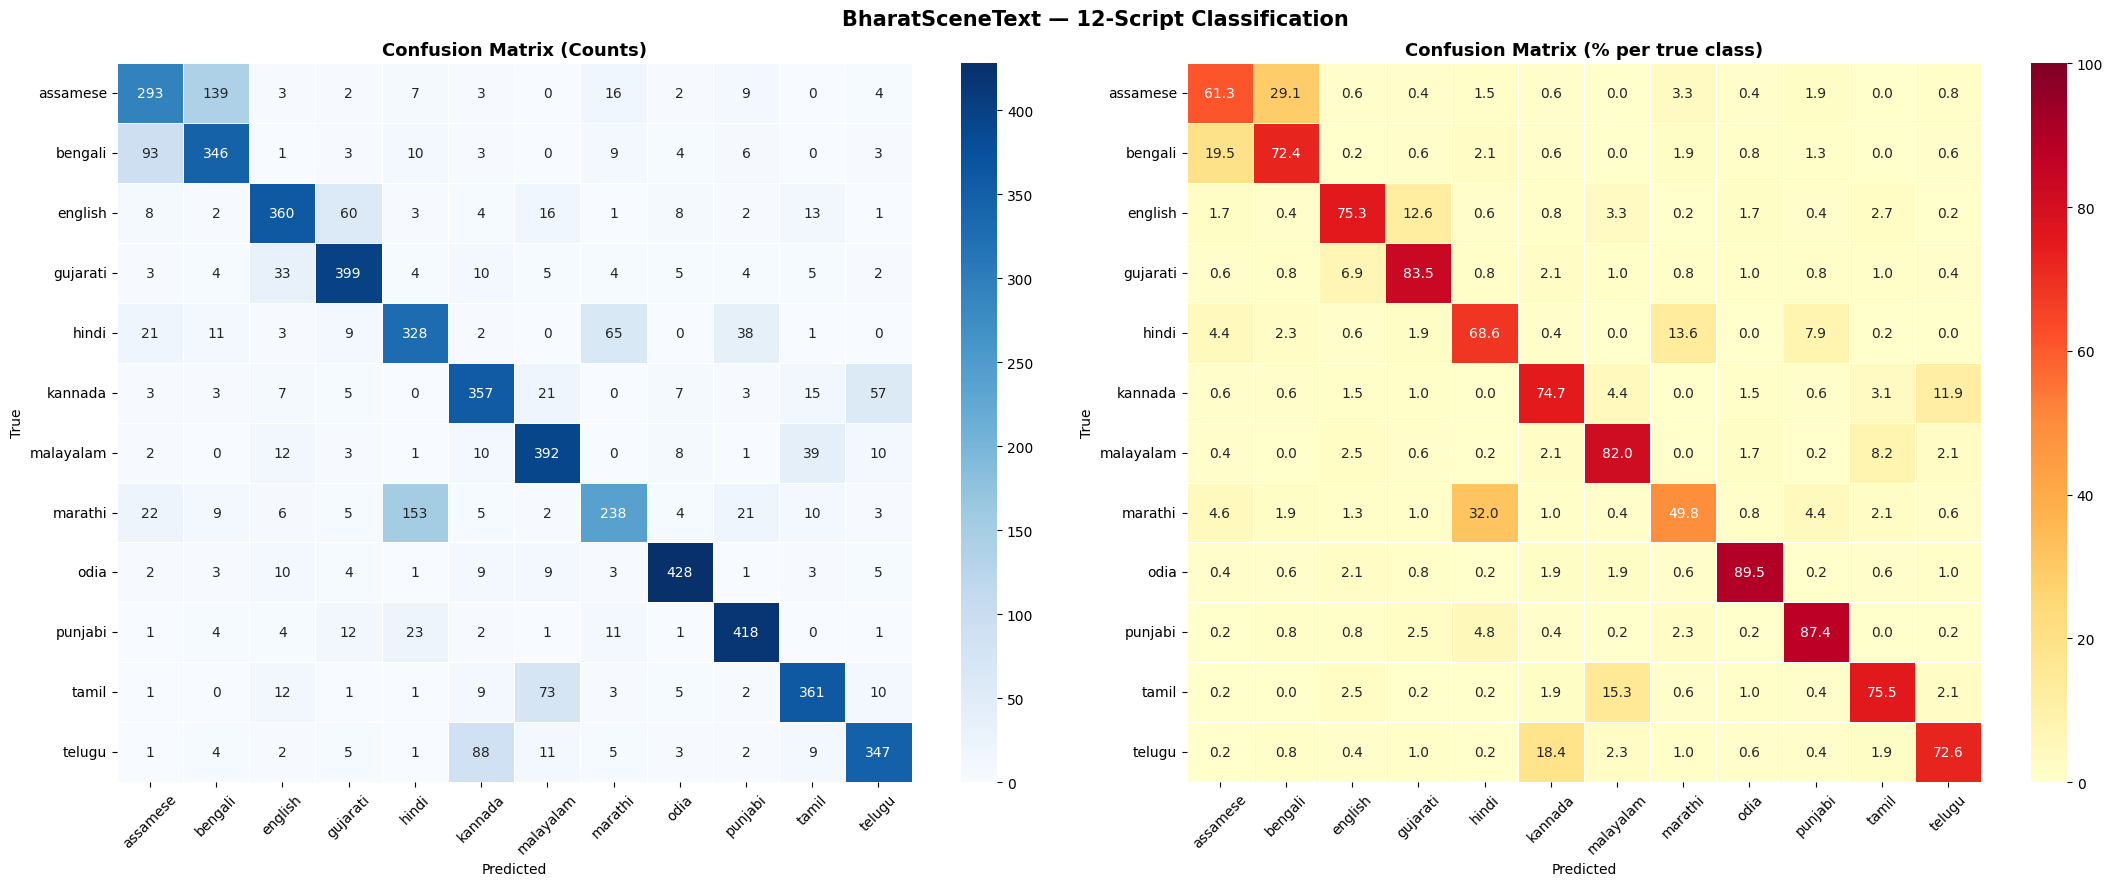

In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ── Raw counts ─────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── Percentages ────────────────────────────────────
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_title("Confusion Matrix (% per true class)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle("BharatSceneText — 12-Script Classification", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)
report_df = pd.DataFrame(report).T.round(4)

# ── Pretty print ───────────────────────────────────
print("=" * 70)
print(f"{'CLASS-WISE ACCURACY REPORT':^70}")
print("=" * 70)

classwise = []
for cls in CLASS_NAMES:
    row = report[cls]
    classwise.append({
        'Script':    cls,
        'Precision': f"{row['precision']*100:.2f}%",
        'Recall':    f"{row['recall']*100:.2f}%",
        'F1-Score':  f"{row['f1-score']*100:.2f}%",
        'Support':   int(row['support'])
    })

cw_df = pd.DataFrame(classwise)
print(cw_df.to_string(index=False))

print("\n" + "=" * 70)
print(f"  Overall Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Balanced Accuracy      : {bal_acc*100:.2f}%")
print(f"  Macro Avg F1           : {report['macro avg']['f1-score']*100:.2f}%")
print(f"  Weighted Avg F1        : {report['weighted avg']['f1-score']*100:.2f}%")
print("=" * 70)

                      CLASS-WISE ACCURACY REPORT                      
   Script Precision Recall F1-Score  Support
 assamese    65.11% 61.30%   63.15%      478
  bengali    65.90% 72.38%   68.99%      478
  english    79.47% 75.31%   77.34%      478
 gujarati    78.54% 83.47%   80.93%      478
    hindi    61.65% 68.62%   64.95%      478
  kannada    71.12% 74.69%   72.86%      478
malayalam    73.96% 82.01%   77.78%      478
  marathi    67.04% 49.79%   57.14%      478
     odia    90.11% 89.54%   89.82%      478
  punjabi    82.45% 87.45%   84.87%      478
    tamil    79.17% 75.52%   77.30%      478
   telugu    78.33% 72.59%   75.35%      478

  Overall Test Accuracy  : 74.39%
  Balanced Accuracy      : 74.39%
  Macro Avg F1           : 74.21%
  Weighted Avg F1        : 74.21%


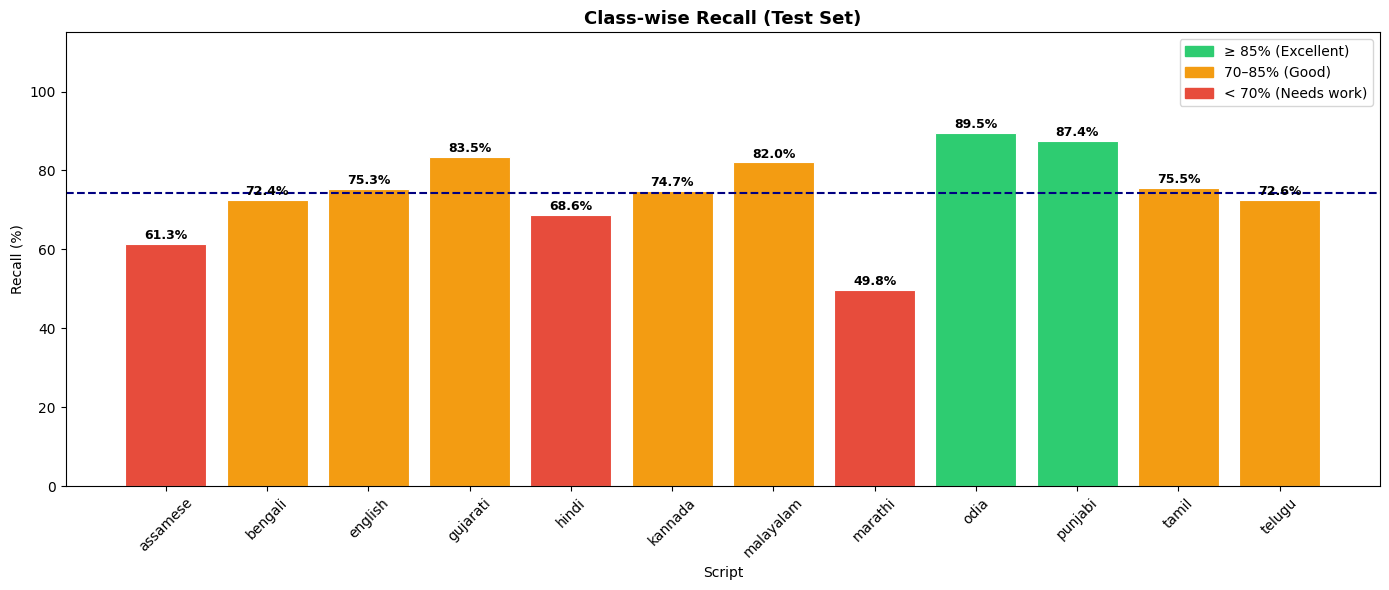

In [15]:
import matplotlib.patches as mpatches
recalls = [report[cls]['recall'] * 100 for cls in CLASS_NAMES]
colors = ['#2ecc71' if r >= 85 else '#f39c12' if r >= 70 else '#e74c3c'
          for r in recalls]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(CLASS_NAMES, recalls, color=colors, edgecolor='white', linewidth=0.8)

# Value labels on bars
for bar, val in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=np.mean(recalls), color='navy', ls='--', lw=1.5,
           label=f'Mean: {np.mean(recalls):.1f}%')
ax.set_ylim(0, 115)
ax.set_title("Class-wise Recall (Test Set)", fontsize=13, fontweight='bold')
ax.set_xlabel("Script"); ax.set_ylabel("Recall (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Legend for colors
patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 85% (Excellent)'),
    mpatches.Patch(color='#f39c12', label='70–85% (Good)'),
    mpatches.Patch(color='#e74c3c', label='< 70% (Needs work)')
]
ax.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig("outputs/classwise_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save full model
model.save("outputs/script_classifier_resnet50v2.keras")
print("✅ Model saved → outputs/script_classifier_resnet50v2.keras")

# ── Final summary table ────────────────────────────
print("\n" + "╔" + "═"*50 + "╗")
print("║" + " 🏆 FINAL RESULTS SUMMARY ".center(50) + "║")
print("╠" + "═"*50 + "╣")
print(f"║  {'Test Accuracy':<28}: {test_acc*100:>7.2f}%        ║")
print(f"║  {'Balanced Accuracy':<28}: {bal_acc*100:>7.2f}%        ║")
print(f"║  {'Macro F1-Score':<28}: {report['macro avg']['f1-score']*100:>7.2f}%        ║")
print(f"║  {'Weighted F1-Score':<28}: {report['weighted avg']['f1-score']*100:>7.2f}%        ║")
best_cls = CLASS_NAMES[np.argmax(recalls)]
worst_cls = CLASS_NAMES[np.argmin(recalls)]
print(f"║  {'Best Class':<28}: {best_cls:<16}   ║")
print(f"║  {'Worst Class':<28}: {worst_cls:<16}   ║")
print("╚" + "═"*50 + "╝")

# Save report CSV
cw_df.to_csv("outputs/classwise_report.csv", index=False)
print("\n📄 Class-wise report saved → outputs/classwise_report.csv")
print("📁 All outputs saved in ./outputs/")

✅ Model saved → outputs/script_classifier_resnet50v2.keras

╔══════════════════════════════════════════════════╗
║             🏆 FINAL RESULTS SUMMARY              ║
╠══════════════════════════════════════════════════╣
║  Test Accuracy               :   74.39%        ║
║  Balanced Accuracy           :   74.39%        ║
║  Macro F1-Score              :   74.21%        ║
║  Weighted F1-Score           :   74.21%        ║
║  Best Class                  : odia               ║
║  Worst Class                 : marathi            ║
╚══════════════════════════════════════════════════╝

📄 Class-wise report saved → outputs/classwise_report.csv
📁 All outputs saved in ./outputs/
